In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import sliding_window

In [4]:
df = pd.read_csv('../dataset/finance/stocks/indicator_dataset.csv')

In [29]:
data = df['raw_adjusted_close'].values[:300]

In [30]:
def smooth(x,window_len=11,window='hanning'):
    """smooth the data using a window with requested size.
    
    This method is based on the convolution of a scaled window with the signal.
    The signal is prepared by introducing reflected copies of the signal 
    (with the window size) in both ends so that transient parts are minimized
    in the begining and end part of the output signal.
    
    input:
        x: the input signal 
        window_len: the dimension of the smoothing window; should be an odd integer
        window: the type of window from 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'
            flat window will produce a moving average smoothing.

    output:
        the smoothed signal
        
    example:

    t=linspace(-2,2,0.1)
    x=sin(t)+randn(len(t))*0.1
    y=smooth(x)
    
    see also: 
    
    numpy.hanning, numpy.hamming, numpy.bartlett, numpy.blackman, numpy.convolve
    scipy.signal.lfilter
 
    TODO: the window parameter could be the window itself if an array instead of a string
    NOTE: length(output) != length(input), to correct this: return y[(window_len/2-1):-(window_len/2)] instead of just y.
    """

    if x.ndim != 1:
        raise (ValueError, "smooth only accepts 1 dimension arrays.")

    if x.size < window_len:
        raise (ValueError, "Input vector needs to be bigger than window size.")


    if window_len<3:
        return x


    if not window in ['flat', 'hanning', 'hamming', 'bartlett', 'blackman']:
        raise (ValueError, "Window is on of 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'")


    s=np.r_[x[window_len-1:0:-1],x,x[-2:-window_len-1:-1]]
    #print(len(s))
    if window == 'flat': #moving average
        w=np.ones(window_len,'d')
    else:
        w=eval('np.'+window+'(window_len)')

    y=np.convolve(w/w.sum(),s,mode='valid')
    return y

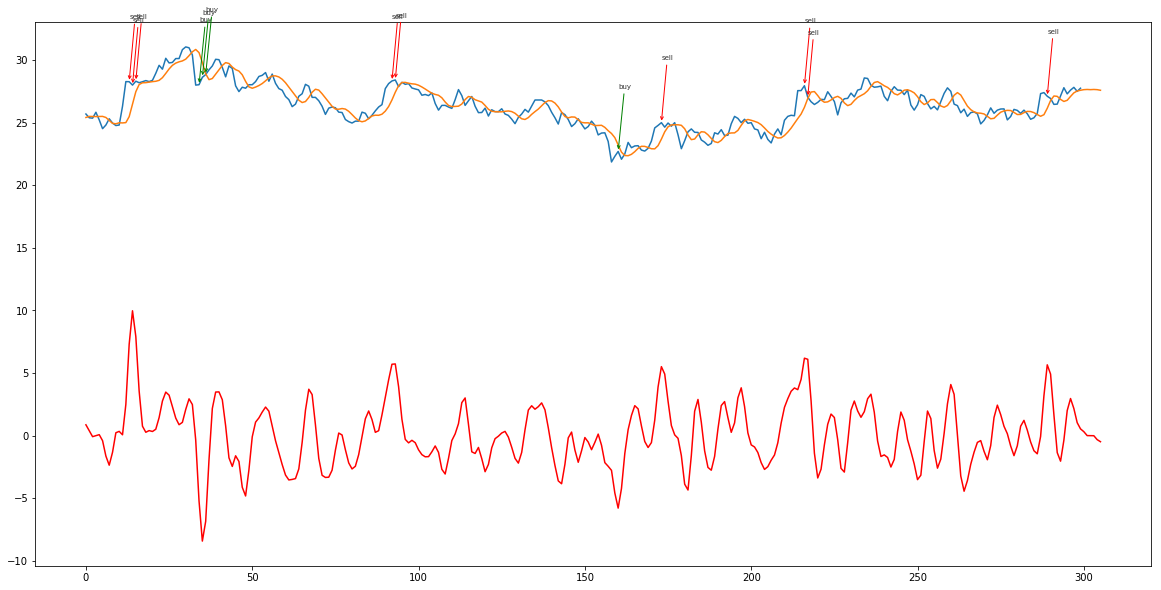

In [68]:
smoothed_data = smooth(data, window_len=7)
gradient_data = np.gradient(smoothed_data)

fig = plt.figure(figsize=(20,10))

plt.plot(data)
plt.plot(smoothed_data)
plt.plot(gradient_data*10, c='r')

# sell labels
arrow_positions = np.where(gradient_data > 0.5)[0]
for arrow_pos in arrow_positions:
    plt.annotate('sell', xy=(arrow_pos, data[arrow_pos]), xycoords='data',
                     xytext=(arrow_pos, data[arrow_pos]+5), textcoords='data', fontsize=7,
                     color='#303030', arrowprops=dict(edgecolor='red', arrowstyle='->', connectionstyle="arc3"))

# buy labels
arrow_positions = np.where(gradient_data < -0.5)[0]
for arrow_pos in arrow_positions:
    plt.annotate('buy', xy=(arrow_pos, data[arrow_pos]), xycoords='data',
                     xytext=(arrow_pos, data[arrow_pos]+5), textcoords='data', fontsize=7,
                     color='#303030', arrowprops=dict(edgecolor='green', arrowstyle='->', connectionstyle="arc3"))

In [143]:
def labelize2(data, window_size=14):
    data_s = sliding_window(data, size=window_size)
    for i, chunk in enumerate(data_s):
        max_idx = i + chunk.argmax()
        min_idx = i + chunk.argmin()
        print('max:', max_idx, data[max_idx])
        print('min:', min_idx, data[min_idx])

def labelize(data, window_size=7):
    maxs, mins=[], []
    for mid_idx in range(window_size//2, len(data) - window_size//2):
        chunk = data[mid_idx-window_size//2:mid_idx+window_size//2+1]
        if chunk.argmax() == window_size//2:
            maxs.append(mid_idx + chunk.argmax()//2+1)
        if chunk.argmin() == window_size//2:
            mins.append(mid_idx + chunk.argmin()//2+1)
    return maxs,mins

In [144]:
maxs, mins = labelize(data=data)

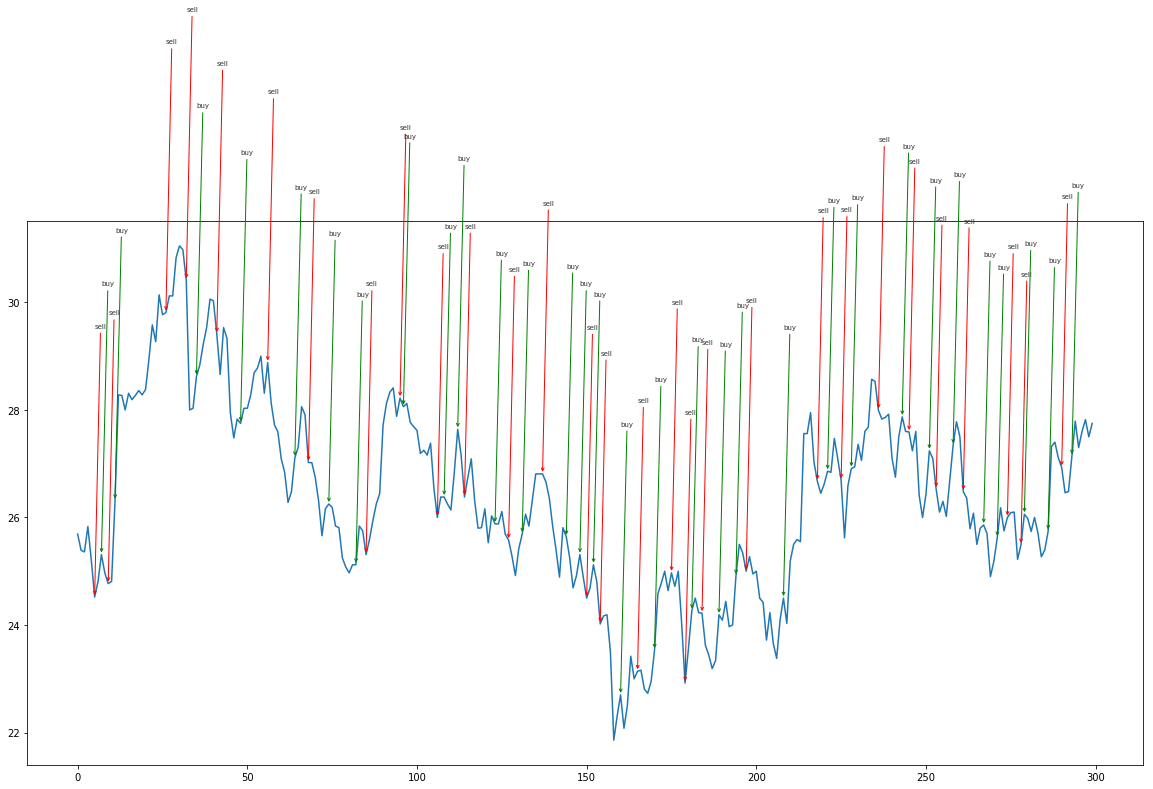

In [145]:
fig = plt.figure(figsize=(20,10))

plt.plot(data)
for arrow_pos in maxs:
    plt.annotate('sell', xy=(arrow_pos, data[arrow_pos]), xycoords='data',
                     xytext=(arrow_pos, data[arrow_pos]+5), textcoords='data', fontsize=7,
                     color='#303030', arrowprops=dict(edgecolor='red', arrowstyle='->', connectionstyle="arc3"))
    
for arrow_pos in mins:
    plt.annotate('buy', xy=(arrow_pos, data[arrow_pos]), xycoords='data',
                     xytext=(arrow_pos, data[arrow_pos]+5), textcoords='data', fontsize=7,
                     color='#303030', arrowprops=dict(edgecolor='green', arrowstyle='->', connectionstyle="arc3"))

In [146]:
a = [3,5,6,1,2,8,2,6,8,9,3,4,6,2]

In [147]:
for mid_idx in range(7//2, len(a) - 7//2):
    chunk = a[mid_idx-7//2:mid_idx+7//2+1]
    print(chunk)
    print('idx:', mid_idx, 'val:',a[mid_idx], 'argmax:', mid_idx//2+np.argmax(chunk)-1, a[mid_idx//2+np.argmax(chunk)-1])

[3, 5, 6, 1, 2, 8, 2]
idx: 3 val: 1 argmax: 5 8
[5, 6, 1, 2, 8, 2, 6]
idx: 4 val: 2 argmax: 5 8
[6, 1, 2, 8, 2, 6, 8]
idx: 5 val: 8 argmax: 4 2
[1, 2, 8, 2, 6, 8, 9]
idx: 6 val: 2 argmax: 8 8
[2, 8, 2, 6, 8, 9, 3]
idx: 7 val: 6 argmax: 7 6
[8, 2, 6, 8, 9, 3, 4]
idx: 8 val: 8 argmax: 7 6
[2, 6, 8, 9, 3, 4, 6]
idx: 9 val: 9 argmax: 6 2
[6, 8, 9, 3, 4, 6, 2]
idx: 10 val: 3 argmax: 6 2


In [75]:
sliding_window(a, size=3)

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4],
       [3, 4, 5],
       [4, 5, 6],
       [5, 6, 7],
       [6, 7, 8],
       [7, 8, 9]])